___
# Atividade: <p> <center> Validação de Modelos, Métricas e ***Data Leakage***
___

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AlexChequer/notebooks-insperai/blob/main/ml-avancado/aula-02-validacao-metricas-leakage.ipynb)

**Trilha de ML/DL Avançado — InsperAI** · o par prático da [Aula 2](https://trilhas-insperai.vercel.app/ml-avancado/aulas/aula-02/)

## Aula 02 — Trilha de Machine Learning e Deep Learning Avançado

**Objetivo da aula:** aprender a montar uma estratégia de validação **correta** e escolher métricas adequadas **antes** de sair criando *features* — a causa nº 1 de modelos que funcionam no notebook e falham em produção é **erro de validação**, não erro de algoritmo. Ao fim desta aula, o aluno será capaz de escolher a estratégia de validação certa para cada tipo de dado, interpretar métricas de classificação e regressão (e saber quando cada uma engana), e identificar e prevenir *data leakage* usando `Pipeline`.

<div id="indice"></div>

## Índice

1. [Introdução](#introducao)
    - [Por que essa aula vem antes de mexer em features?](#porque-antes)
    - [Preparando a base de dados](#preparando)

<p>

2. [Estratégias de validação](#validacao)
    - [Hold-out simples (e sua limitação)](#holdout)
    - [K-fold cross-validation](#kfold)
    - [Stratified K-fold](#stratified)
    - [Group K-fold](#group)
    - [Validação temporal (time series split)](#temporal)

<p>

3. [Métricas de classificação](#classificacao)
    - [A matriz de confusão](#matriz-confusao)
    - [Acurácia: quando ela engana](#acuracia)
    - [Precisão, recall e F1-score](#precisao-recall)
    - [AUC-ROC e AUC-PR](#auc)

<p>

4. [Métricas de regressão](#regressao)
    - [MAE, RMSE, MAPE e R²](#mae-rmse)

<p>

5. [*Data leakage*: o "vilão silencioso"](#leakage)
    - [Vazamento de target](#leak-target)
    - [Vazamento via pré-processamento antes do split](#leak-preproc)
    - [Vazamento temporal](#leak-temporal)

<p>

6. [Boas práticas: `Pipeline` e `ColumnTransformer`](#pipeline)

<p>

7. [Aplicação no mercado](#mercado)

<p>

8. [**EXERCÍCIOS**](#exercicios)

<p>

9. [Resumo dos comandos](#resumo-comandos)

<p>

10. [Vídeos de apoio](#videos)

___
<div id="introducao"></div>

## 1. Introdução

<div id="porque-antes"></div>

### Por que essa aula vem antes de mexer em features?

Essa é, possivelmente, a aula mais "cara" da trilha em termos de **evitar erros graves**: qualquer transformação feita nos dados **antes** de definir corretamente a estratégia de validação corre o risco de "vazar" informação do conjunto de teste para o treino — inflando artificialmente as métricas durante o desenvolvimento e fazendo o modelo parecer muito melhor do que realmente é... até falhar quando colocado em produção com dados verdadeiramente novos. <p>
**A regra de ouro:** o conjunto de teste simula "o futuro" — dados que o modelo nunca viu. Qualquer informação dele que influencie o treino (mesmo indiretamente, via uma média ou um desvio-padrão) contamina a avaliação.

In [1]:
# Importando as bibliotecas necessárias para esta atividade
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     KFold, StratifiedKFold, GroupKFold, TimeSeriesSplit)
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn import metrics

<div id="preparando"></div>

### Preparando a base de dados

Vamos usar a base `titanic`  com o objetivo de **modelar** `survived`. <br>
Para os primeiros exemplos, montamos uma versão numérica simples da base (a forma *correta* de tratar faltantes e categóricas dentro da validação será vista na Seção 6 — repare que aqui, por enquanto, apenas **descartamos** linhas com faltantes, para não cometermos o erro que esta aula ensina a evitar!).

**ATENÇÃO:** é necessário estar conectado à internet para carregar a base.

In [2]:
dados = sns.load_dataset('titanic')

# Versão numérica simples: sexo vira 0/1 e descartamos linhas com faltantes
base = dados[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']].copy()
base['sex'] = base['sex'].map({'male': 0, 'female': 1})
base = base.dropna()

X = base.drop(columns='survived')
y = base['survived']

print(f'Base pronta: {X.shape[0]} passageiros e {X.shape[1]} features.')
print(f'Proporção de sobreviventes: {y.mean():.1%}')

Base pronta: 714 passageiros e 6 features.
Proporção de sobreviventes: 40.6%


[Voltar ao Índice](#indice)

___
<div id="validacao"></div>

## 2. Estratégias de validação

<div id="holdout"></div>

### Hold-out simples (e sua limitação)

**Hold-out** é a estratégia mais simples: dividir o dataset em duas partes (ex: 80% treino, 20% teste) **uma única vez**. <br>
A limitação: o resultado pode **variar bastante** dependendo de qual "fatia" aleatória caiu no teste — principalmente em datasets pequenos. Veja com seus próprios olhos:

Acurácias em 10 hold-outs diferentes: mínima = 0.734 | máxima = 0.846
Amplitude: 0.112 — só mudando a semente aleatória!


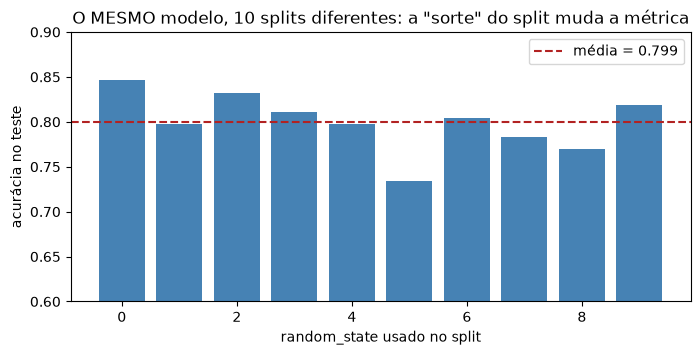

In [3]:
acuracias = []

for semente in range(10):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=semente)
    modelo = LogisticRegression(max_iter=1000)
    modelo.fit(X_tr, y_tr)
    acuracias.append(modelo.score(X_te, y_te))

acuracias = pd.Series(acuracias)
print(f'Acurácias em 10 hold-outs diferentes: mínima = {acuracias.min():.3f} | máxima = {acuracias.max():.3f}')
print(f'Amplitude: {(acuracias.max() - acuracias.min()):.3f} — só mudando a semente aleatória!')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(range(10), acuracias, color='steelblue')
ax.axhline(acuracias.mean(), color='firebrick', linestyle='--', label=f'média = {acuracias.mean():.3f}')
ax.set_xlabel('random_state usado no split')
ax.set_ylabel('acurácia no teste')
ax.set_title('O MESMO modelo, 10 splits diferentes: a "sorte" do split muda a métrica')
ax.set_ylim(0.6, 0.9)
ax.legend()
plt.show()

...<p>
**Reflita/discuta:** se você reportasse apenas o resultado do melhor split, estaria mentindo para si mesmo? Qual dos 10 números é "o verdadeiro" desempenho do modelo?

<div id="kfold"></div>

### K-fold cross-validation

O **K-fold** divide os dados em K "fatias" (*folds*, ex: K=5); treina-se o modelo K vezes, cada vez usando K-1 fatias para treino e a fatia restante para teste. A métrica final é a **média** entre as K rodadas — uma estimativa muito mais robusta, porque **todos** os dados passam pelo teste (em rodadas diferentes).

In [4]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(LogisticRegression(max_iter=1000), X, y, cv=kfold)

print(f'Acurácia em cada fold: {np.round(scores, 3)}')
print(f'Média ± desvio: {scores.mean():.3f} ± {scores.std():.3f}')

Acurácia em cada fold: [0.748 0.769 0.804 0.867 0.803]
Média ± desvio: 0.798 ± 0.040


...<p>
Repare: em vez de **um** número (que depende da sorte do split), agora temos **média ± desvio** — sabemos o desempenho típico **e** o quanto ele varia. É assim que se reporta resultado de modelo.

<div id="stratified"></div>

### Stratified K-fold

O **Stratified K-fold** garante que a **proporção das classes** seja mantida em cada fatia — essencial quando as classes são desbalanceadas. Sem estratificação, algumas fatias poderiam, por azar, ficar quase sem exemplos da classe minoritária. <br>
Vamos criar um problema **bem** desbalanceado (5% de "fraude") para ver a diferença:

In [5]:
from sklearn.datasets import make_classification

# Dataset sintético desbalanceado: 95% classe 0, 5% classe 1 ("fraude")
X_fraude, y_fraude = make_classification(n_samples=1000, n_features=10, weights=[0.95],
                                         random_state=42)
print(f'Proporção da classe 1 (fraude) no dataset: {y_fraude.mean():.1%}\n')

for nome, cv in [('KFold comum   ', KFold(5, shuffle=True, random_state=0)),
                 ('StratifiedKFold', StratifiedKFold(5, shuffle=True, random_state=0))]:
    proporcoes = [y_fraude[teste].mean() for _, teste in cv.split(X_fraude, y_fraude)]
    print(f'{nome} — % de fraude em cada fold de teste: {np.round(proporcoes, 3)}')

Proporção da classe 1 (fraude) no dataset: 5.3%

KFold comum    — % de fraude em cada fold de teste: [0.05  0.065 0.055 0.02  0.075]
StratifiedKFold — % de fraude em cada fold de teste: [0.05  0.05  0.055 0.055 0.055]


...<p>
No `KFold` comum a proporção de fraude **oscila** entre os folds (um fold pode ter quase o dobro de fraudes que outro); no `StratifiedKFold`, todos os folds têm a mesma proporção — a avaliação fica comparável entre folds.

<div id="group"></div>

### Group K-fold

Usado quando existem **grupos de observações que não podem ser separados** entre treino e teste (ex: várias transações do **mesmo cliente**, várias imagens do **mesmo paciente**). <br>
Sem isso, o modelo poderia "decorar" características daquele cliente no treino e "reconhecê-lo" no teste — uma falsa sensação de boa performance que **não generaliza** para clientes novos.

In [6]:
# Simulação: 12 transações de apenas 4 clientes (A, B, C, D)
grupos = np.array(['A', 'A', 'A', 'B', 'B', 'B', 'C', 'C', 'C', 'D', 'D', 'D'])
X_transacoes = np.arange(12).reshape(-1, 1)

gkf = GroupKFold(n_splits=4)
for i, (treino, teste) in enumerate(gkf.split(X_transacoes, groups=grupos)):
    print(f'Fold {i+1}: clientes no treino = {sorted(set(grupos[treino]))} | '
          f'cliente no teste = {sorted(set(grupos[teste]))}')

Fold 1: clientes no treino = [np.str_('A'), np.str_('B'), np.str_('C')] | cliente no teste = [np.str_('D')]
Fold 2: clientes no treino = [np.str_('A'), np.str_('B'), np.str_('D')] | cliente no teste = [np.str_('C')]
Fold 3: clientes no treino = [np.str_('A'), np.str_('C'), np.str_('D')] | cliente no teste = [np.str_('B')]
Fold 4: clientes no treino = [np.str_('B'), np.str_('C'), np.str_('D')] | cliente no teste = [np.str_('A')]


...<p>
Repare: cada cliente aparece **inteiro** no treino **ou** no teste — nunca nos dois. É exatamente esse o comportamento que queremos.

<div id="temporal"></div>

### Validação temporal (time series split)

Para dados sequenciais no tempo, **nunca** use K-fold tradicional (que embaralha os dados) — isso permitiria que o modelo "veja o futuro" durante o treino, o que é impossível na vida real. <br>
A validação temporal **sempre treina com o passado e testa com o futuro**, em janelas progressivas:

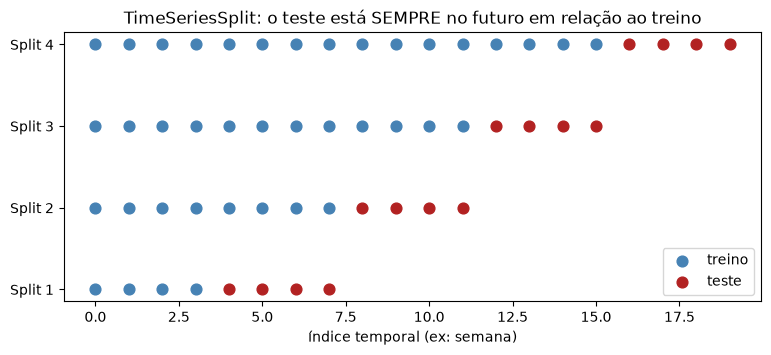

In [7]:
tscv = TimeSeriesSplit(n_splits=4)
serie = np.arange(20)

fig, ax = plt.subplots(figsize=(9, 3.5))
for i, (treino, teste) in enumerate(tscv.split(serie)):
    ax.scatter(treino, [i] * len(treino), color='steelblue', s=60,
               label='treino' if i == 0 else None)
    ax.scatter(teste, [i] * len(teste), color='firebrick', s=60,
               label='teste' if i == 0 else None)
ax.set_yticks(range(4), [f'Split {i+1}' for i in range(4)])
ax.set_xlabel('índice temporal (ex: semana)')
ax.set_title('TimeSeriesSplit: o teste está SEMPRE no futuro em relação ao treino')
ax.legend()
plt.show()

[Voltar ao Índice](#indice)

___
<div id="classificacao"></div>

## 3. Métricas de classificação

<div id="matriz-confusao"></div>

### A matriz de confusão

Antes das métricas, é essencial entender a **matriz de confusão**, que organiza os resultados de um classificador binário em 4 categorias:

- **Verdadeiro Positivo (VP)**: o modelo previu positivo, e era positivo mesmo;
- **Falso Positivo (FP)**: o modelo previu positivo, mas era negativo (erro tipo I);
- **Falso Negativo (FN)**: o modelo previu negativo, mas era positivo (erro tipo II); e
- **Verdadeiro Negativo (VN)**: o modelo previu negativo, e era negativo mesmo.

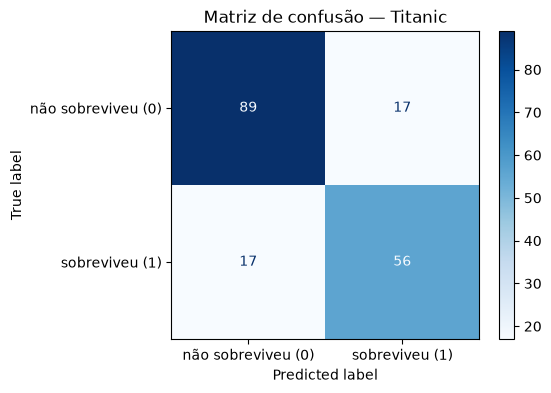

In [8]:
# Treinamos um modelo em um hold-out fixo para explorar as métricas
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_tr, y_tr)
y_pred = modelo.predict(X_te)

fig, ax = plt.subplots(figsize=(5, 4))
metrics.ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred, display_labels=['não sobreviveu (0)', 'sobreviveu (1)'],
    cmap='Blues', ax=ax)
ax.set_title('Matriz de confusão — Titanic')
plt.show()

<div id="acuracia"></div>

### Acurácia: quando ela engana

$$\text{Acurácia} = \frac{VP + VN}{Total}$$

É a proporção geral de acertos. **Cuidado:** enganosa em datasets desbalanceados. Veja o clássico exemplo da fraude — um modelo "preguiçoso" que **sempre** prevê "não fraude":

In [9]:
X_ftr, X_fte, y_ftr, y_fte = train_test_split(X_fraude, y_fraude, test_size=0.3,
                                              stratify=y_fraude, random_state=42)

preguicoso = DummyClassifier(strategy='most_frequent')   # sempre prevê a classe majoritária
preguicoso.fit(X_ftr, y_ftr)
y_fpred = preguicoso.predict(X_fte)

print(f'Acurácia do modelo preguiçoso: {metrics.accuracy_score(y_fte, y_fpred):.1%}')
print(f'Fraudes detectadas (recall):   {metrics.recall_score(y_fte, y_fpred):.1%}')

Acurácia do modelo preguiçoso: 94.7%
Fraudes detectadas (recall):   0.0%


...<p>
**95% de acurácia sem detectar UMA fraude sequer.** A acurácia sozinha não diz nada em problemas desbalanceados — precisamos de métricas que "olhem" para a classe que importa.

<div id="precisao-recall"></div>

### Precisão, recall e F1-score

- **Precisão** $= \frac{VP}{VP + FP}$ — *"das vezes que o modelo disse positivo, quantas ele acertou?"* Importante quando o custo de um **falso positivo** é alto (ex: marcar transação legítima como fraude e incomodar um cliente honesto);
- **Recall (sensibilidade)** $= \frac{VP}{VP + FN}$ — *"de todos os positivos reais, quantos o modelo capturou?"* Importante quando o custo de um **falso negativo** é alto (ex: deixar passar uma fraude real, não detectar uma doença grave); e
- **F1-score** = média **harmônica** entre precisão e recall — útil quando queremos equilíbrio entre as duas, especialmente em datasets desbalanceados.

In [10]:
print(metrics.classification_report(y_te, y_pred,
                                    target_names=['não sobreviveu', 'sobreviveu']))

                precision    recall  f1-score   support

não sobreviveu       0.84      0.84      0.84       106
    sobreviveu       0.77      0.77      0.77        73

      accuracy                           0.81       179
     macro avg       0.80      0.80      0.80       179
  weighted avg       0.81      0.81      0.81       179



<div id="auc"></div>

### AUC-ROC e AUC-PR

O modelo não produz só "0 ou 1" — ele produz uma **probabilidade**, e o rótulo depende do limiar de decisão (por padrão, 0.5). As curvas abaixo avaliam o modelo em **todos os limiares possíveis**.

**Curva ROC** — plota TPR (recall) vs. FPR em cada limiar:

$$TPR = \frac{VP}{VP+FN} \qquad FPR = \frac{FP}{FP+VN}$$

**Curva Precision-Recall (PR)** — plota Precisão vs. Recall em cada limiar:

$$\text{Precisão} = \frac{VP}{VP+FP} \qquad \text{Recall} = \frac{VP}{VP+FN}$$

**Por que a ROC "engana" em dataset desbalanceado:** o problema mora no FPR. Ele tem VN no denominador — e quando a classe negativa é enorme (ex: 95% dos dados), até um modelo que gera muitos falsos positivos em número absoluto tem FPR minúsculo, porque está dividindo por uma quantidade gigante de negativos. Resultado: a curva ROC (e sua AUC) pode parecer ótima mesmo quando o modelo é inútil na prática.

**Por que a PR é melhor nesse cenário:** a Precisão tem FP e VP no denominador — ambos ligados à classe positiva/rara, sem nenhum VN envolvido. Isso a torna sensível exatamente ao que importa quando a classe positiva é escassa: "das vezes que o modelo gritou positivo, quantas eram reais?". Por isso, **AUC-PR costuma ser mais informativa que a AUC-ROC quando a classe positiva é rara** (fraude, doença rara, defeito de fabricação).

Regra prática: dataset desbalanceado + interesse na classe minoritária → prefira **PR-AUC** (ou *average precision*). ROC-AUC continua útil quando as classes são mais equilibradas ou quando FP e FN têm custo/prevalência parecidos.

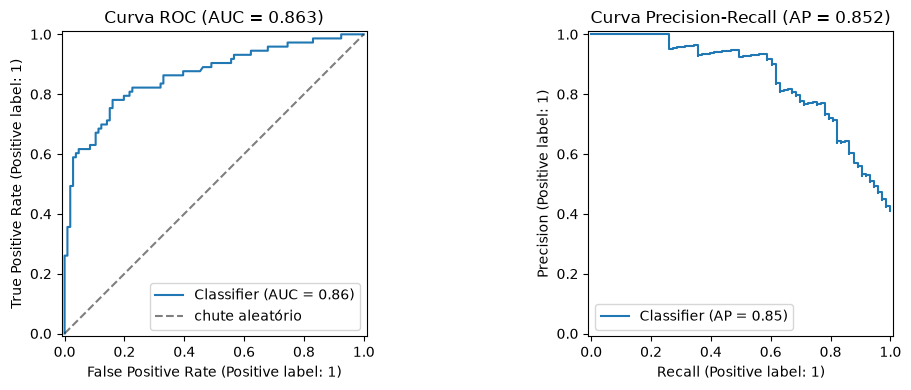

In [11]:
y_prob = modelo.predict_proba(X_te)[:, 1]   # probabilidade da classe 1

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

metrics.RocCurveDisplay.from_predictions(y_te, y_prob, ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='chute aleatório')
axes[0].set_title(f'Curva ROC (AUC = {metrics.roc_auc_score(y_te, y_prob):.3f})')
axes[0].legend()

metrics.PrecisionRecallDisplay.from_predictions(y_te, y_prob, ax=axes[1])
axes[1].set_title(f'Curva Precision-Recall (AP = {metrics.average_precision_score(y_te, y_prob):.3f})')

plt.tight_layout()
plt.show()

No Titanic (40.6% de sobreviventes) as classes estão relativamente equilibradas, então ROC e PR contam praticamente a mesma história. O efeito descrito acima só aparece de verdade quando a classe positiva é **rara** — vamos usar o dataset sintético de fraude (`X_fraude`, `y_fraude`, só 5.3% de positivos) criado na Seção 2 para ver a diferença na prática.

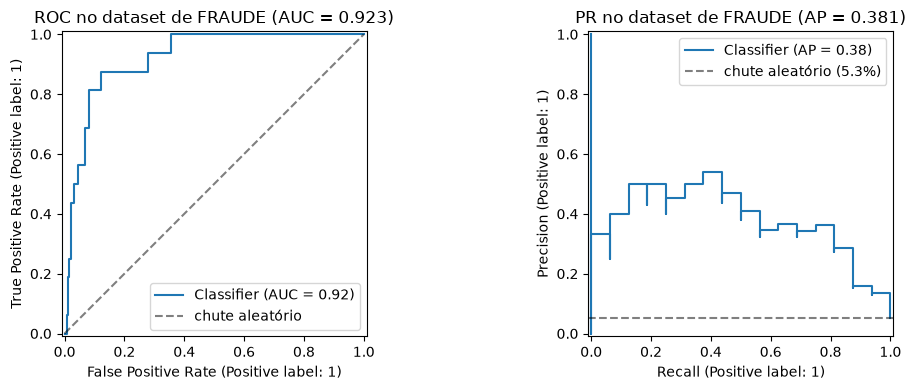

AUC-ROC = 0.923  (parece ótimo)
AUC-PR  = 0.381  (revela que ainda há bastante espaço para melhorar)


In [12]:
# Treinamos um modelo no dataset de fraude (5.3% de positivos) e comparamos ROC vs. PR
X_ftr, X_fte, y_ftr, y_fte = train_test_split(X_fraude, y_fraude, test_size=0.3,
                                              stratify=y_fraude, random_state=42)

modelo_fraude = LogisticRegression(max_iter=1000)
modelo_fraude.fit(X_ftr, y_ftr)
y_fprob = modelo_fraude.predict_proba(X_fte)[:, 1]

roc_auc = metrics.roc_auc_score(y_fte, y_fprob)
pr_auc = metrics.average_precision_score(y_fte, y_fprob)
linha_base_pr = y_fte.mean()   # o "chute aleatório" na curva PR é a prevalência da classe positiva

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

metrics.RocCurveDisplay.from_predictions(y_fte, y_fprob, ax=axes[0])
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='chute aleatório')
axes[0].set_title(f'ROC no dataset de FRAUDE (AUC = {roc_auc:.3f})')
axes[0].legend()

metrics.PrecisionRecallDisplay.from_predictions(y_fte, y_fprob, ax=axes[1])
axes[1].axhline(linha_base_pr, color='k', linestyle='--', alpha=0.5,
                label=f'chute aleatório ({linha_base_pr:.1%})')
axes[1].set_title(f'PR no dataset de FRAUDE (AP = {pr_auc:.3f})')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'AUC-ROC = {roc_auc:.3f}  (parece ótimo)')
print(f'AUC-PR  = {pr_auc:.3f}  (revela que ainda há bastante espaço para melhorar)')

**Veja o contraste:** AUC-ROC ≈ **0.92** — olhando só para esse número, o modelo parece excelente. Mas AUC-PR ≈ **0.38** — bem mais perto da linha de base (5.3%, a prevalência da fraude) do que do topo (1.0). São o mesmo modelo, nas mesmas previsões; a diferença é qual pergunta cada curva está fazendo. <br>
A ROC pouco se abala porque o FPR usa VN (abundantes) no denominador; a PR expõe o problema porque a Precisão usa FP e VP (ambos ligados à classe rara) no denominador. Se você reportasse só a AUC-ROC para justificar colocar esse modelo em produção, estaria escondendo (sem querer) o quão pouco confiável ele é quando *alerta* fraude.

[Voltar ao Índice](#indice)

___
<div id="regressao"></div>

## 4. Métricas de regressão

<div id="mae-rmse"></div>

### MAE, RMSE, MAPE e R²

- **MAE** (*Mean Absolute Error*): média do valor absoluto dos erros — fácil de interpretar (mesma unidade da variável), trata todos os erros com o mesmo peso;
- **RMSE** (*Root Mean Squared Error*): eleva os erros ao quadrado antes de tirar a média — **penaliza mais os erros grandes**, sendo mais sensível a outliers que o MAE;
- **MAPE** (*Mean Absolute Percentage Error*): erro percentual, intuitivo para comunicar a stakeholders — mas "explode" quando o valor real está próximo de zero; e
- **R²**: proporção da variância do alvo que o modelo explica (1 = ajuste perfeito). Cuidado: R² **sempre** aumenta ao adicionar variáveis, mesmo irrelevantes — por isso existe o R² ajustado.
    - R² = 1 → previsão perfeita
    - R² = 0 → seu modelo é tão bom quanto simplesmente chutar a média sempre
    - R² < 0 (negativo!) → seu modelo é pior do que chutar a média — é isso que aconteceu nos dois exemplos do notebook

Vamos ver como um **único erro grande** afeta cada métrica de forma diferente:

In [13]:
y_real = np.array([100, 120, 90, 110, 105, 95])

# Modelo A: erra pouco em tudo (erro de ~10 em cada previsão)
pred_A = np.array([110, 110, 100, 100, 115, 85])
# Modelo B: acerta quase tudo, mas comete UM erro grande (o último: 95 -> 155)
pred_B = np.array([101, 119, 91, 111, 104, 155])

for nome, pred in [('A (erros pequenos e constantes)', pred_A),
                   ('B (um único erro grande)       ', pred_B)]:
    mae = metrics.mean_absolute_error(y_real, pred)
    rmse = np.sqrt(metrics.mean_squared_error(y_real, pred))
    mape = metrics.mean_absolute_percentage_error(y_real, pred)
    r2 = metrics.r2_score(y_real, pred)
    print(f'Modelo {nome}: MAE = {mae:5.2f} | RMSE = {rmse:5.2f} | MAPE = {mape:.1%} | R² = {r2:6.3f}')

Modelo A (erros pequenos e constantes): MAE = 10.00 | RMSE = 10.00 | MAPE = 9.8% | R² = -0.029
Modelo B (um único erro grande)       : MAE = 10.83 | RMSE = 24.51 | MAPE = 11.3% | R² = -5.180


...<p>
Os dois modelos têm o **mesmo MAE** — mas o RMSE do modelo B é bem maior, porque o quadrado "amplifica" o erro grande. <br>
**Reflita/discuta:** para prever demanda de estoque, qual erro é pior — errar um pouco todo dia, ou acertar quase sempre e errar feio uma vez? A resposta define se você deve olhar MAE ou RMSE.

[Voltar ao Índice](#indice)

___
<div id="leakage"></div>

## 5. *Data leakage*: o "vilão silencioso"

*Data leakage* (vazamento de dados) é quando informação que **não estaria disponível na hora da previsão real** contamina o treino do modelo. O modelo fica ótimo no papel — e inútil na prática. Vamos ver os três tipos principais **acontecendo**.

<div id="leak-target"></div>

### Vazamento de target

Uma feature que, direta ou indiretamente, **já contém a resposta**. A base `titanic` do Seaborn tem um exemplo perfeito escondido: a coluna `alive` (vivo?) é literalmente o próprio `survived` escrito com outras palavras!

In [14]:
# Adicionando a feature "alive" (yes/no) ao modelo... o que poderia dar errado?
base_leak = dados[['survived', 'pclass', 'sex', 'age', 'fare', 'alive']].copy()
base_leak['sex'] = base_leak['sex'].map({'male': 0, 'female': 1})
base_leak['alive'] = base_leak['alive'].map({'no': 0, 'yes': 1})
base_leak = base_leak.dropna()

X_leak = base_leak.drop(columns='survived')
y_leak = base_leak['survived']

scores_leak = cross_val_score(LogisticRegression(max_iter=1000), X_leak, y_leak, cv=5)
print(f'Acurácia com a feature "alive": {scores_leak.mean():.1%}  <- bom demais para ser verdade!')

Acurácia com a feature "alive": 100.0%  <- bom demais para ser verdade!


...<p>
**100% de acurácia deveria acender um alarme, não uma comemoração.** Na vida real, o vazamento raramente é tão óbvio — costuma ser uma feature como "número de dias internado" para prever internação, ou "limite aprovado" para prever aprovação de crédito. <br>
**Regra prática:** desempenho perfeito (ou quase) = procure o vazamento antes de comemorar.

<div id="leak-preproc"></div>

### Vazamento via pré-processamento antes do split

O erro mais **sutil** e mais **comum**: usar o dataset inteiro (treino + teste) para calcular estatísticas de pré-processamento (normalização, imputação, seleção de features) **antes** de separar os conjuntos. <p>
A demonstração a seguir é dramática: um dataset de **puro ruído aleatório** (não existe NENHUMA relação real com o alvo). Selecionamos as features mais correlacionadas com o alvo usando **todos os dados** e depois validamos — veja o desastre:

In [15]:
rng = np.random.default_rng(42)

# 100 amostras, 1000 features de PURO RUÍDO, alvo aleatório: acurácia real possível = ~50%
X_ruido = rng.normal(size=(100, 1000))
y_ruido = rng.integers(0, 2, size=100)

# ERRADO: escolher as 20 features mais correlacionadas com o alvo USANDO TODOS OS DADOS...
correlacoes = np.array([abs(np.corrcoef(X_ruido[:, j], y_ruido)[0, 1]) for j in range(1000)])
melhores = np.argsort(correlacoes)[-20:]

# ...e SÓ DEPOIS fazer a validação cruzada
scores_errado = cross_val_score(LogisticRegression(max_iter=1000),
                                X_ruido[:, melhores], y_ruido, cv=5)
print(f'Acurácia (seleção ANTES do split): {scores_errado.mean():.1%}  <- em dados 100% aleatórios!')

Acurácia (seleção ANTES do split): 81.0%  <- em dados 100% aleatórios!


In [16]:
# CERTO: a seleção de features acontece DENTRO de cada fold, vendo apenas o treino
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectKBest, f_classif

pipe_correto = Pipeline([
    ('selecao', SelectKBest(f_classif, k=20)),
    ('modelo', LogisticRegression(max_iter=1000)),
])

scores_certo = cross_val_score(pipe_correto, X_ruido, y_ruido, cv=5)
print(f'Acurácia (seleção DENTRO do pipeline): {scores_certo.mean():.1%}  <- agora sim: nível do acaso.')

Acurácia (seleção DENTRO do pipeline): 55.0%  <- agora sim: nível do acaso.


...<p>
O mesmo procedimento, mudando apenas **onde** a seleção acontece: ~80% (mentira) vs. ~55% (verdade — o nível do acaso, com a folga estatística de uma base pequena). <br>
Se as features fossem escolhidas olhando os dados de teste, o teste deixa de ser teste. O `Pipeline` refaz a seleção **dentro de cada fold**, usando só o treino daquele fold — por isso o resultado é honesto.

<div id="leak-temporal"></div>

### Vazamento temporal

Usar, durante o treino, **informação do futuro** em relação ao momento da previsão. Exemplo clássico: prever se um cliente vai cancelar o serviço usando a feature "número de reclamações no mês seguinte ao cancelamento" — essa informação não existiria na hora de prever. <br>
Outras formas comuns: embaralhar séries temporais no K-fold (visto na Seção 2) e calcular médias móveis/estatísticas usando janelas que incluem o futuro. **Antídoto:** `TimeSeriesSplit` + disciplina ao construir features de data (assunto da Aula 3!).

[Voltar ao Índice](#indice)

___
<div id="pipeline"></div>

## 6. Boas práticas: `Pipeline` e `ColumnTransformer`

O `Pipeline` garante que qualquer transformação (normalização, imputação, encoding) seja **ajustada (`fit`) apenas nos dados de treino** e depois apenas **aplicada (`transform`)** nos dados de teste — nunca ajustada usando o teste. Isso vale dentro de cada fold da validação cruzada, automaticamente. <br>
O `ColumnTransformer` permite aplicar tratamentos **diferentes** para colunas numéricas e categóricas. Essa é considerada prática **essencial** de mercado, não um "nice to have".

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Agora podemos usar a base COMPLETA (com faltantes e categóricas), sem dropna!
X_completo = dados[['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
y_completo = dados['survived']

colunas_numericas = ['age', 'sibsp', 'parch', 'fare']
colunas_categoricas = ['pclass', 'sex', 'embarked']

preprocessador = ColumnTransformer([
    ('num', Pipeline([('imputa', SimpleImputer(strategy='median')),
                      ('escala', StandardScaler())]), colunas_numericas),
    ('cat', Pipeline([('imputa', SimpleImputer(strategy='most_frequent')),
                      ('onehot', OneHotEncoder(handle_unknown='ignore'))]), colunas_categoricas),
])

pipeline_final = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo', LogisticRegression(max_iter=1000)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_final = cross_val_score(pipeline_final, X_completo, y_completo, cv=cv)
print(f'Acurácia do pipeline completo: {scores_final.mean():.3f} ± {scores_final.std():.3f}')
print(f'(usando TODOS os {len(X_completo)} passageiros, sem descartar linhas com faltantes)')

Acurácia do pipeline completo: 0.797 ± 0.015
(usando TODOS os 891 passageiros, sem descartar linhas com faltantes)


...<p>
Repare no ganho de **processo**: imputação da mediana, padronização e *one-hot encoding* são recalculados **dentro de cada fold**, só com o treino — zero vazamento, zero esforço manual. E ainda aproveitamos os 891 passageiros (na Seção 1 tínhamos jogado fora ~180 linhas com o `dropna`).

[Voltar ao Índice](#indice)

___
<div id="mercado"></div>

## 7. Aplicação no mercado

*Data leakage* é uma das causas mais comuns — e mais **caras** — de modelos que têm métricas excelentes durante o desenvolvimento, mas falham completamente em produção. Saber identificar e prevenir isso é frequentemente avaliado em **entrevistas técnicas**, e é requisito essencial em **auditorias de modelo** em setores regulados (financeiro, saúde, seguros). <br>
A dupla `Pipeline` + validação cruzada estratificada é o "arroz com feijão" profissional: qualquer notebook sem isso levanta suspeita em um code review de um time maduro de ML.

___
<div id="exercicios"></div>

## 8. EXERCÍCIOS

### EXERCÍCIO 1 — Hold-out vs. K-fold

1. Rode um hold-out (80/20) com 5 valores diferentes de `random_state` e registre a acurácia de cada um.
2. Rode uma validação cruzada com `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` no mesmo modelo.
3. Compare: qual é a amplitude (máx - mín) dos hold-outs? E o desvio-padrão do K-fold?
4. Se você tivesse que reportar **um** número para seu gestor, qual estratégia usaria e por quê?

In [18]:
# Coloque seu código aqui...

### EXERCÍCIO 2 — Estratificação em dados desbalanceados

Usando o dataset sintético de fraude (`X_fraude`, `y_fraude`) criado na Seção 2:

1. Rode `cross_val_score` com `KFold(5, shuffle=True, random_state=0)` e depois com `StratifiedKFold(5, shuffle=True, random_state=0)`, usando `scoring='recall'` e uma `LogisticRegression(max_iter=1000)`.
2. Compare a **variação do recall entre os folds** nas duas estratégias.
3. Explique por que a estratificação estabiliza a avaliação nesse caso.

In [19]:
# Coloque seu código aqui...

### EXERCÍCIO 3 — Escolhendo o limiar (e a métrica) certo

O modelo de sobrevivência da Seção 3 produz probabilidades (`y_prob`). O limiar padrão é 0.5, mas ele **não é sagrado**:

1. Para os limiares 0.3, 0.5 e 0.7, gere as previsões (`y_prob >= limiar`) e calcule **precisão** e **recall** de cada uma.
2. O que acontece com a precisão e com o recall conforme o limiar aumenta? Por quê?
3. Agora imagine dois cenários de negócio: (a) triagem de uma doença grave (não podemos perder nenhum doente); (b) bloqueio automático de cartão por suspeita de fraude (bloquear cliente honesto custa caro). Qual limiar (baixo ou alto) você usaria em cada cenário? Justifique usando os conceitos de FP e FN.

In [20]:
# Coloque seu código aqui...

### EXERCÍCIO 4 — Caça ao vazamento

O código abaixo foi escrito por um estagiário e reporta uma acurácia altíssima (rode e veja!). Ele contém **DOIS vazamentos de dados**. Encontre-os, explique cada um, e reescreva o código da forma correta (a acurácia vai cair — e isso é **bom**):

```python
base_estagiario = dados[['survived', 'pclass', 'sex', 'age', 'fare', 'who', 'alive']].copy()
base_estagiario['sex'] = base_estagiario['sex'].map({'male': 0, 'female': 1})
base_estagiario['alive'] = base_estagiario['alive'].map({'no': 0, 'yes': 1})
base_estagiario['who'] = base_estagiario['who'].map({'man': 0, 'woman': 1, 'child': 2})

# imputação da média usando a base inteira
base_estagiario['age'] = base_estagiario['age'].fillna(base_estagiario['age'].mean())

X_est = base_estagiario.drop(columns='survived')
y_est = base_estagiario['survived']
print(cross_val_score(LogisticRegression(max_iter=1000), X_est, y_est, cv=5).mean())
```

*Dica:* um vazamento é uma **coluna**; o outro é uma **ordem de operações**. Qual dos dois infla mais a métrica? Qual é mais difícil de perceber em um projeto real?

In [21]:
# Coloque seu código aqui...

### EXERCÍCIO 5 — Pipeline completo

Partindo do `pipeline_final` da Seção 6:

1. Adicione a coluna `deck` às features categóricas (ela tem ~77% de faltantes — use uma estratégia de imputação que crie uma categoria própria, ex: `SimpleImputer(strategy='constant', fill_value='desconhecido')`).
2. Avalie com a mesma validação cruzada estratificada e compare com o resultado sem `deck`.
3. A coluna ajudou, atrapalhou ou ficou igual? Conecte sua conclusão com o que a Aula 01 mostrou sobre o padrão de ausência de `deck` (MNAR — a ausência em si carrega informação!).

In [22]:
# Coloque seu código aqui...

[Voltar ao Índice](#indice)

___
<div id="resumo-comandos"></div>

## 9. Resumo dos comandos

Faça um resumo das funções apresentadas nesta atividade:

- `train_test_split()`: EXPLIQUE AQUI;
- `cross_val_score()`: EXPLIQUE AQUI;
- `KFold` / `StratifiedKFold`: EXPLIQUE AQUI;
- `GroupKFold`: EXPLIQUE AQUI;
- `TimeSeriesSplit`: EXPLIQUE AQUI;
- `confusion_matrix` / `ConfusionMatrixDisplay`: EXPLIQUE AQUI;
- `classification_report()`: EXPLIQUE AQUI;
- `roc_auc_score()` / `average_precision_score()`: EXPLIQUE AQUI;
- `mean_absolute_error()` / `mean_squared_error()`: EXPLIQUE AQUI;
- `Pipeline`: EXPLIQUE AQUI; e
- `ColumnTransformer`: EXPLIQUE AQUI.

___
<div id="videos"></div>

## 10. Vídeos de apoio (do material da trilha)

Marcados como **[Intuitivo]** (constrói a ideia) e **[Técnico]** (entra na matemática/implementação — assista depois do intuitivo, não no lugar dele):

1. **[Intuitivo]** StatQuest with Josh Starmer — *"Machine Learning Fundamentals: Cross Validation"* (busque esse título exato no YouTube);
2. **[Intuitivo]** StatQuest with Josh Starmer — *"ROC and AUC, Clearly Explained!"* (complementa muito bem a explicação de precisão/recall/AUC);
3. **[Técnico]** *"Data Leakage Explained Visually | How Models Cheat Without You Realizing"* — https://youtu.be/xzCXqYlV2HE; e
4. **[Técnico]** Yuriy Guts — *"Target Leakage in Machine Learning"* (palestra AI Ukraine Conference) — https://youtu.be/dWhdWxgt5SU (mais avançado, com casos reais de mercado).

**Próxima aula:** Feature Engineering Avançado — agora que sabemos validar **sem vazamentos**, podemos criar features com segurança.

[Voltar ao Índice](#indice)